## Mashiur Rahman

# Assignment 14: Ethical AI Analysis and Explainability

## 1. Introduction to Ethical AI

Ethical Artificial Intelligence ensures that machine learning systems are fair, transparent, accountable, and free from harmful discrimination. A model may produce good overall accuracy while treating demographic groups differently. Therefore, both performance and fairness must be evaluated.

In this project, a logistic regression model predicts whether an individual's annual income is greater than $50,000. The model is evaluated using accuracy, a confusion matrix, and a classification report. Fairlearn is used to compare results across sex groups. SHAP and LIME are used to explain how the model makes predictions.

# 2. Import Libraries

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Fairness analysis
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate
)

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("All required libraries were imported successfully.")

All required libraries were imported successfully.


# Part 1: Dataset Preparation

## 2. Dataset Description

The Adult Income dataset is a public dataset containing demographic and employment information collected from United States census data. Its target variable identifies whether an individual's annual income is greater than $50,000.

The dataset contains numerical features, such as age, education number, capital gain, and hours worked per week. It also contains categorical features, such as work class, occupation, marital status, race, and sex.

For this analysis:

- **Target variable:** Income greater than $50,000
- **Sensitive attribute:** Sex
- **Positive prediction:** Annual income greater than $50,000

In [5]:
# Column names supplied by the Adult dataset documentation
column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

# Public URL for the Adult Income dataset
data_url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/adult/adult.data"
)

# Load the dataset
df = pd.read_csv(
    data_url,
    names=column_names,
    na_values="?",
    skipinitialspace=True
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Output Explanation

The dataset was loaded from the UCI Machine Learning Repository. The shape shows that the dataset contains 32,561 records and 15 columns. The displayed table provides a preview of the demographic, education, and employment variables.

# 6. Inspect the Dataset

In [6]:
# Display general information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### Output Explanation

The dataset information displays the column names, data types, number of non-null values, and memory usage. Numerical columns use integer data types, while categorical columns use object data types. A difference between the total number of rows and the non-null count indicates missing values.

# Clean the Target Variable

In [8]:
# Select all categorical text columns
categorical_columns_all = df.select_dtypes(
    include=["object", "string"]
).columns

# Remove extra spaces from categorical columns
for column in categorical_columns_all:
    df[column] = df[column].str.strip()

# Convert income into a binary target:
# 1 = income greater than $50,000
# 0 = income less than or equal to $50,000
df["income_binary"] = df["income"].apply(
    lambda value: 1 if value == ">50K" else 0
)

print("Target variable distribution:")
print(df["income_binary"].value_counts())

print("\nTarget variable percentage:")
print(
    (df["income_binary"].value_counts(normalize=True) * 100).round(2)
)

Target variable distribution:
income_binary
0    24720
1     7841
Name: count, dtype: int64

Target variable percentage:
income_binary
0    75.92
1    24.08
Name: proportion, dtype: float64


### Output Explanation

The income variable was converted into a binary target. A value of 0 represents annual income of $50,000 or less, while a value of 1 represents annual income greater than $50,000.

The results show that 24,720 individuals (75.92%) belong to the lower-income class, while 7,841 individuals (24.08%) belong to the higher-income class. Therefore, the target variable is imbalanced because the lower-income class contains substantially more records.

## Examine the Sensitive Attribute

Sensitive attribute distribution:
sex
Male      21790
Female    10771
Name: count, dtype: int64


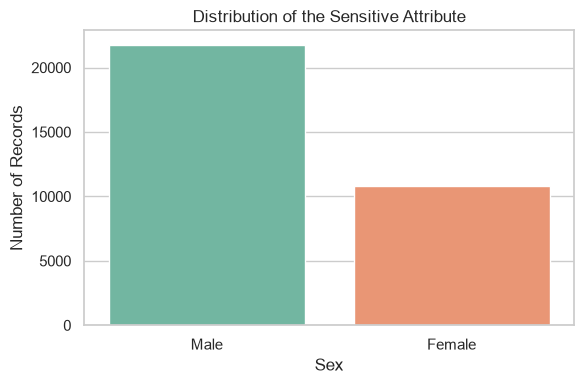

In [9]:
# Examine the sensitive attribute
print("Sensitive attribute distribution:")
print(df["sex"].value_counts())

# Visualize the sensitive attribute
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex", hue="sex", palette="Set2", legend=False)
plt.title("Distribution of the Sensitive Attribute")
plt.xlabel("Sex")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Output Explanation

Sex is selected as the sensitive attribute for the fairness analysis. The table and bar chart show the number of records in each group. The groups are not equally represented, which is important because unequal representation can influence model training and fairness results.

## Select Features and Target

In [10]:
# Remove the original text target and the binary target from the features
X = df.drop(columns=["income", "income_binary"])

# Define the binary target
y = df["income_binary"]

# Save the sensitive attribute separately for fairness analysis
sensitive_feature = df["sex"]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Sensitive feature:", sensitive_feature.name)

Feature dataset shape: (32561, 14)
Target shape: (32561,)
Sensitive feature: sex


### Output Explanation

The feature matrix X contains the variables used by the model. The target y indicates whether income is greater than $50,000. Sex is stored separately so that model performance can later be compared across sensitive groups.

## Split the Dataset

In [11]:
# Split the features, target, and sensitive attribute together
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = (
    train_test_split(
        X,
        y,
        sensitive_feature,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

# Reset the sensitive feature index for Fairlearn
sensitive_test = sensitive_test.reset_index(drop=True)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (26048, 14)
Testing feature shape: (6513, 14)
Training target shape: (26048,)
Testing target shape: (6513,)


### Output Explanation
The dataset was divided into 80% training data and 20% testing data. The training data is used to teach the model, while the testing data measures performance on unseen records. Stratification maintains approximately the same income-class distribution in both sets.

## Create the Preprocessing Pipeline

In [13]:
# Identify numerical and categorical features

# Select numerical columns
numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

# Select categorical text columns
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


### Output Explanation
The dataset features were separated into numerical and categorical groups. Six features were identified as numerical, while eight features were identified as categorical.

Numerical features will be standardized, while categorical features will be converted into numerical indicator columns using one-hot encoding. This preparation is necessary because logistic regression requires numerical input.

In [14]:
# Preprocessing for numerical features
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Output Explanation

The preprocessing pipeline handles missing numerical values with the median and missing categorical values with the most frequent category. Numerical variables are standardized, and categorical variables are one-hot encoded. This converts all features into a form that logistic regression can process.

# Part 2: Model Training and Evaluation

## Model Training

Logistic regression is a supervised classification algorithm that estimates the probability of a binary outcome. It was selected because it is suitable for binary classification and its coefficients can be interpreted more easily than those of many complex models.

In [15]:
# Create a pipeline containing preprocessing and logistic regression
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic regression model trained successfully.")

Logistic regression model trained successfully.


### Output Explanation

The logistic regression model was trained using the preprocessed training data. The balanced class-weight setting gives additional importance to the less frequent high-income class and helps the model learn from both target classes.

## Make Predictions

In [16]:
# Predict target classes for the testing data
y_pred = model.predict(X_test)

# Predict probabilities for the positive class
y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 probabilities of income greater than $50K:")
print(np.round(y_probability[:10], 3))

First 10 predicted classes:
[0 0 1 1 0 0 0 1 1 0]

First 10 probabilities of income greater than $50K:
[0.319 0.035 0.998 0.76  0.253 0.06  0.075 0.776 0.567 0.223]


### Output Explanation

The first output contains predicted classes, where 0 represents income at or below $50,000 and 1 represents income above $50,000. The second output contains the model's estimated probability that each individual belongs to the high-income class.

## Calculate Model Accuracy

In [17]:
# Calculate overall prediction accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.4f}")
print(f"Model accuracy percentage: {accuracy * 100:.2f}%")

Model accuracy: 0.8075
Model accuracy percentage: 80.75%


## Create the Confusion Matrix

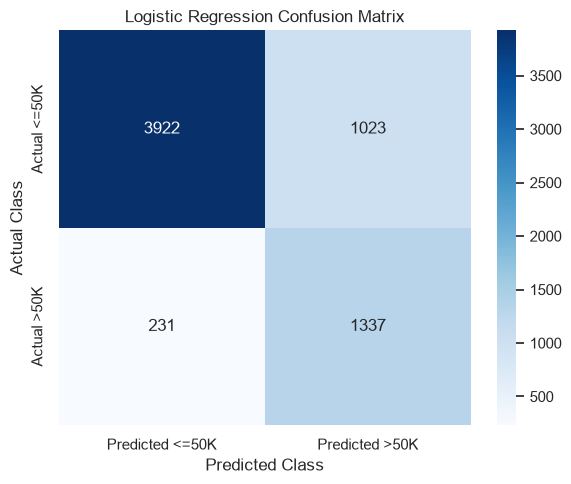

Confusion matrix:
[[3922 1023]
 [ 231 1337]]


In [18]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted <=50K", "Predicted >50K"],
    yticklabels=["Actual <=50K", "Actual >50K"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm)

### Output Explanation

The confusion matrix summarizes four types of results:

- **True negatives:** Lower-income individuals correctly classified as lower income.
- **False positives:** Lower-income individuals incorrectly classified as higher income.
- **False negatives:** Higher-income individuals incorrectly classified as lower income.
- **True positives:** Higher-income individuals correctly classified as higher income.

This analysis shows the types of mistakes made by the model instead of reporting only overall accuracy.

## Generate the Classification Report

In [19]:
# Generate detailed evaluation metrics
report = classification_report(
    y_test,
    y_pred,
    target_names=["Income <=50K", "Income >50K"]
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

Income <=50K       0.94      0.79      0.86      4945
 Income >50K       0.57      0.85      0.68      1568

    accuracy                           0.81      6513
   macro avg       0.76      0.82      0.77      6513
weighted avg       0.85      0.81      0.82      6513



### Output Explanation

The classification report presents precision, recall, F1-score, and support for each income class.

- **Precision** measures how many positive predictions were correct.
- **Recall** measures how many actual positive cases were identified.
- **F1-score** balances precision and recall.
- **Support** shows the number of actual records in each class.

Differences between the two classes can occur because the dataset contains more lower-income than higher-income records.

# Part 3: Fairness Analysis

##  Fairness Analysis

Fairness is evaluated across the sex groups using the following metrics:

- **Selection rate:** Proportion of people predicted to earn more than $50,000.
- **True positive rate:** Proportion of actual high-income individuals correctly identified.
- **False positive rate:** Proportion of actual lower-income individuals incorrectly classified as high income.
- **Accuracy:** Proportion of correct predictions within each group.

Similar values across groups suggest more comparable model behaviour. Large differences can indicate potential unfairness, although the social context and underlying data distribution must also be considered.

In [20]:
# Create a collection of fairness metrics
fairness_metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "true_positive_rate": true_positive_rate,
    "false_positive_rate": false_positive_rate
}

# Create a MetricFrame
metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test.reset_index(drop=True),
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

print("Overall model metrics:")
display(metric_frame.overall.to_frame(name="Overall"))

print("\nMetrics by sensitive group:")
display(metric_frame.by_group)

Overall model metrics:


,Overall
accuracy,0.807462
selection_rate,0.362352
true_positive_rate,0.852679
false_positive_rate,0.206876



Metrics by sensitive group:


,accuracy,selection_rate,true_positive_rate,false_positive_rate
sex,,,,
Female,0.911956,0.151529,0.779592,0.071093
Male,0.755683,0.466820,0.866213,0.292546


### Output Explanation

The overall table reports performance for the complete testing dataset. The group table reports accuracy, selection rate, true positive rate, and false positive rate separately for females and males.

A difference in selection rates means that the groups receive positive high-income predictions at different rates. Differences in true positive or false positive rates indicate that the types of model errors are not distributed equally across the groups.

## Calculate Fairness Differences

In [21]:
# Calculate the difference between the highest and lowest group result
fairness_difference = metric_frame.difference()

# Calculate the ratio between the lowest and highest group result
fairness_ratio = metric_frame.ratio()

print("Difference between groups:")
display(fairness_difference.to_frame(name="Difference"))

print("\nRatio between groups:")
display(fairness_ratio.to_frame(name="Ratio"))

Difference between groups:


,Difference
accuracy,0.156272
selection_rate,0.315291
true_positive_rate,0.086621
false_positive_rate,0.221454



Ratio between groups:


,Ratio
accuracy,0.828640
selection_rate,0.324599
true_positive_rate,0.900000
false_positive_rate,0.243013


### Output Explanation

The difference measures the distance between the best-performing and worst-performing group for each metric. A value closer to zero indicates a smaller group difference.

The ratio compares the lowest group result with the highest group result. A value closer to one indicates greater similarity between groups. These measures help identify whether one group receives substantially different model outcomes.

## Visualize Fairness Metrics

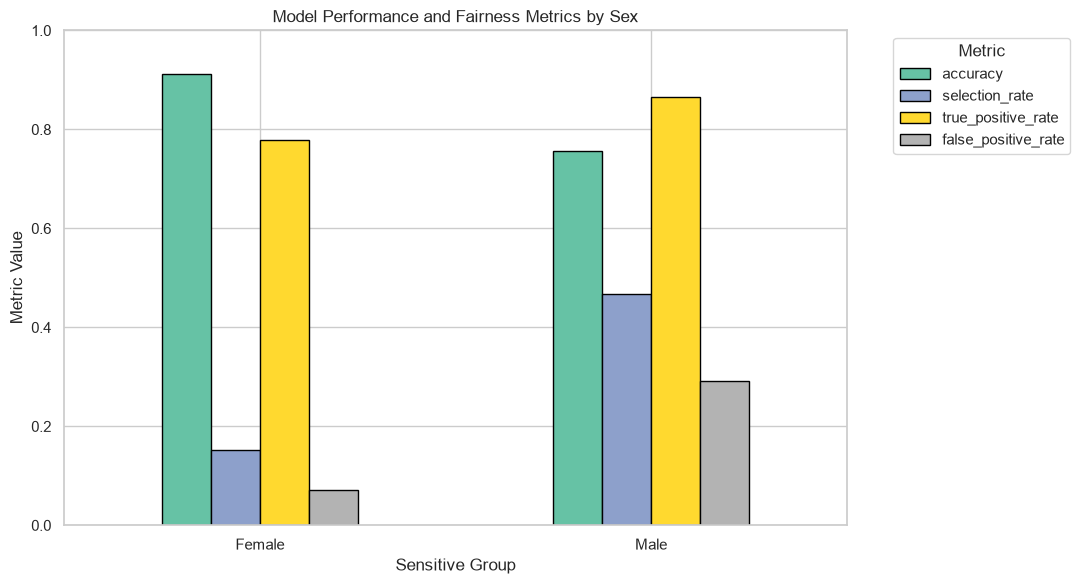

In [22]:
# Store group metrics in a DataFrame
group_metrics = metric_frame.by_group.copy()

# Create grouped bar charts
axes = group_metrics.plot(
    kind="bar",
    figsize=(11, 6),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Model Performance and Fairness Metrics by Sex")
plt.xlabel("Sensitive Group")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Output Explanation

The bar chart visually compares model metrics across the sensitive groups. Bars with similar heights indicate more comparable outcomes. Noticeable differences in selection rate, true positive rate, or false positive rate suggest that the model behaves differently across groups and may require fairness improvements.

# Part 4: SHAP Explainability

## 5. SHAP Explainability Analysis

SHAP stands for Shapley Additive Explanations. It assigns an importance value to each feature by estimating how much that feature increases or decreases a model prediction.

A SHAP summary plot provides global explainability by showing the most influential features across many predictions. A SHAP waterfall plot provides local explainability by showing how individual features affected one specific prediction.

In [23]:
# Access the fitted preprocessing component
fitted_preprocessor = model.named_steps["preprocessor"]

# Transform the training and testing data
X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

# Obtain the feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print("Number of transformed features:", len(feature_names))

Processed training shape: (26048, 105)
Processed testing shape: (6513, 105)
Number of transformed features: 105


### Output Explanation

The original data was transformed using the fitted preprocessing pipeline. One-hot encoding expands categorical variables into multiple binary columns, so the processed dataset contains more columns than the original dataset. The transformed feature names will be used in the SHAP and LIME explanations.

## Create a SHAP Explainer

In [25]:
# Access the trained logistic regression classifier
trained_classifier = model.named_steps["classifier"]

# Select 100 background records to make SHAP faster
background_data = shap.sample(
    X_train_processed,
    100,
    random_state=42
)

# Create the SHAP linear explainer
shap_explainer = shap.LinearExplainer(
    trained_classifier,
    background_data
)

# Calculate SHAP values for the first 300 testing records
shap_values = shap_explainer(
    X_test_processed[:300]
)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully.
SHAP values shape: (300, 105)


### Output Explanation

The SHAP explainer calculates the contribution of every transformed feature to each model prediction. The shape shows the number of explained testing records and the number of model features.

## Generate a SHAP Summary Plot

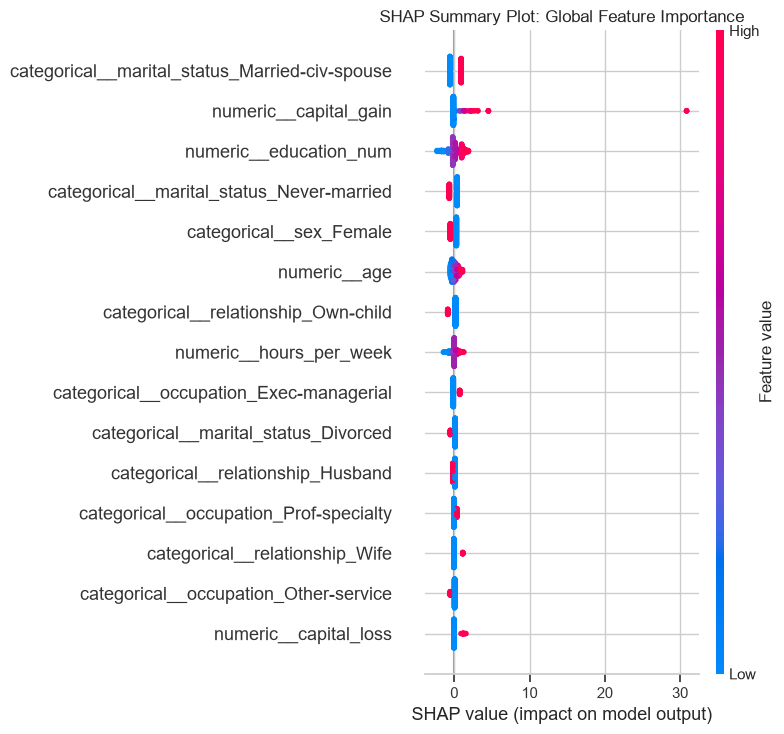

In [26]:
# Create the global SHAP summary plot
shap.summary_plot(
    shap_values.values,
    X_test_processed[:300],
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot: Global Feature Importance")
plt.tight_layout()
plt.show()

### Output Explanation

The SHAP summary plot identifies the features with the greatest overall influence on model predictions.

Features are ordered from most important to least important. Points to the right increase the model's prediction toward income above $50,000, while points to the left decrease it. Red generally represents higher feature values and blue represents lower values.

If sex-related variables appear among the influential features, this indicates that the sensitive attribute contributes to the model's decisions and should be reviewed carefully.

## Display Mean SHAP Importance

In [27]:
# Calculate mean absolute SHAP importance
mean_shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_shap_importance
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).head(15)

display(shap_importance_df)

,Feature,Mean_Absolute_SHAP
32,categorical__marital_status_Married-civ-spouse,0.724875
3,numeric__capital_gain,0.702483
2,numeric__education_num,0.600811
34,categorical__marital_status_Never-married,0.475278
62,categorical__sex_Female,0.361929
0,numeric__age,0.314609
54,categorical__relationship_Own-child,0.271662
5,numeric__hours_per_week,0.251906
40,categorical__occupation_Exec-managerial,0.202176
30,categorical__marital_status_Divorced,0.172263


### Output Explanation

The table ranks the 15 most important model features according to their mean absolute SHAP values. A larger value means that the feature has a greater average effect on predictions. This provides a numeric version of the global SHAP summary plot.

## Generate a SHAP Waterfall Plot

Actual class: 0
Predicted class: 0
Probability of income greater than $50K: 0.3189


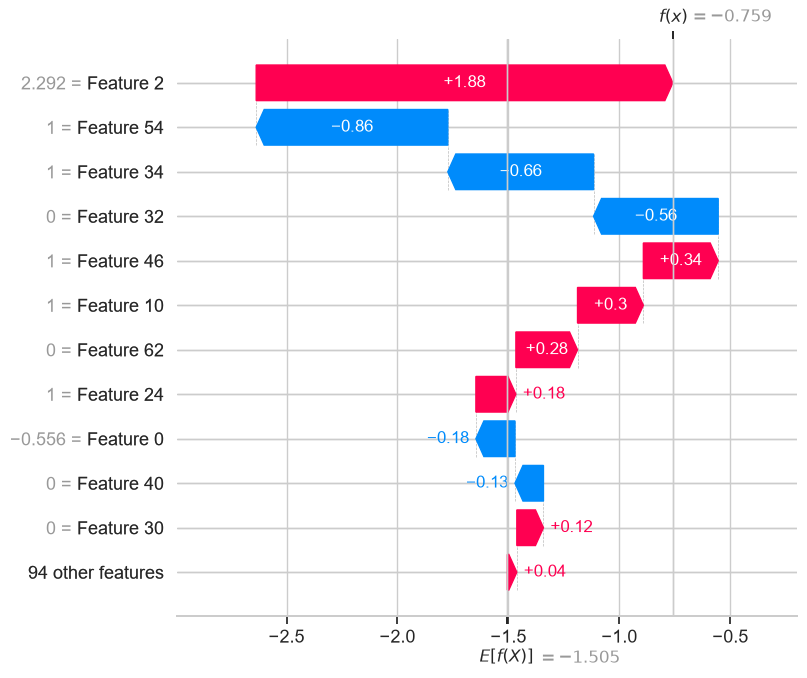

In [28]:
# Select an individual testing record
record_number = 0

# Display its actual and predicted results
print("Actual class:", y_test.iloc[record_number])
print("Predicted class:", y_pred[record_number])
print(
    "Probability of income greater than $50K:",
    round(y_probability[record_number], 4)
)

# Display the SHAP waterfall explanation
shap.plots.waterfall(
    shap_values[record_number],
    max_display=12
)

### Output Explanation

The waterfall plot explains one individual prediction. It begins with the model's average or baseline output and shows how individual features move the prediction higher or lower.

Red features push the prediction toward the high-income class, while blue features push it toward the lower-income class. The final value represents the model output for the selected individual.

# Part 5: LIME Explainability

##  LIME Explainability Analysis

LIME stands for Local Interpretable Model-agnostic Explanations. It explains one prediction by creating small variations around the selected record and fitting a simple interpretable model in that local area.

Unlike SHAP's global summary, LIME mainly focuses on explaining why the model produced a particular prediction for one individual.

In [29]:
# Create the LIME tabular explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_processed),
    feature_names=list(feature_names),
    class_names=["Income <=50K", "Income >50K"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


### Output Explanation

The LIME explainer was created using the transformed training data, feature names, and target-class names. It can now analyze individual predictions made by the trained logistic regression model.

## Explain an Individual Prediction with LIME

In [30]:
# Select one testing record
lime_record_number = 0

# Generate the LIME explanation
lime_explanation = lime_explainer.explain_instance(
    data_row=np.asarray(X_test_processed[lime_record_number]),
    predict_fn=trained_classifier.predict_proba,
    num_features=10
)

print("Actual class:", y_test.iloc[lime_record_number])
print("Predicted class:", y_pred[lime_record_number])
print(
    "Probability of income greater than $50K:",
    round(y_probability[lime_record_number], 4)
)

print("\nLIME feature contributions:")
for feature, contribution in lime_explanation.as_list():
    print(f"{feature}: {contribution:.4f}")

Actual class: 0
Predicted class: 0
Probability of income greater than $50K: 0.3189

LIME feature contributions:
numeric__capital_gain <= -0.15: -0.5357
categorical__native_country_Cambodia <= 0.00: -0.2877
categorical__native_country_South <= 0.00: 0.2606
numeric__education_num > 0.74: 0.2278
categorical__marital_status_Married-civ-spouse <= 0.00: -0.2117
categorical__native_country_Dominican-Republic <= 0.00: 0.2072
categorical__occupation_Priv-house-serv <= 0.00: 0.1866
categorical__native_country_Columbia <= 0.00: 0.1839
categorical__relationship_Wife <= 0.00: -0.1753
categorical__native_country_Thailand <= 0.00: -0.0674


### Output Explanation

The LIME output lists the ten features that had the greatest influence on the selected prediction. Positive contribution values generally support the predicted high-income class, while negative values move the prediction toward the lower-income class.

LIME provides a local explanation, so its findings apply mainly to the selected individual and should not automatically be treated as global model behaviour.

## Visualize the LIME Explanation

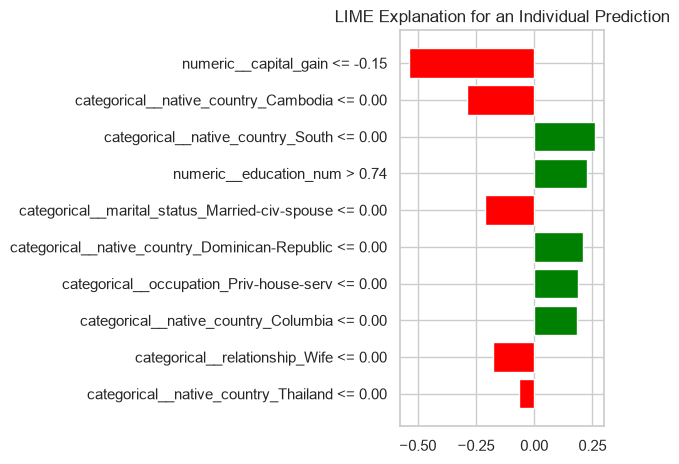

In [31]:
# Create a LIME explanation chart
lime_explanation.as_pyplot_figure()

plt.title("LIME Explanation for an Individual Prediction")
plt.tight_layout()
plt.show()

### Output Explanation

The LIME chart shows the features that supported or opposed the selected prediction. The length of each bar represents the strength of that feature's local contribution. This makes the individual prediction more transparent and easier to review.

# Part 6: Ethical Discussion and Recommendations

##  Fairness Findings and Ethical Considerations

The model's fairness cannot be judged from overall accuracy alone. The Fairlearn results compare selection rate, true positive rate, false positive rate, and accuracy across the sex groups.

If one group has a substantially lower selection rate, members of that group are less frequently predicted to have income above $50,000. A difference in true positive rate means that qualified positive cases are identified at different rates. A difference in false positive rate means that incorrect positive decisions are not equally distributed.

These differences do not automatically prove intentional discrimination. They may result from historical inequalities, unequal group representation, correlations between demographic and employment variables, or direct use of the sensitive attribute. However, they provide evidence that the model should be investigated before being used in a real decision-making system.

SHAP provides both global and individual explanations, while LIME explains individual predictions. These techniques improve transparency, but an explanation does not automatically make a model fair or ethical.

## Recommendations

## 8. Recommendations for Improving Fairness

The following actions are recommended:

1. Remove sex from the prediction features and compare the new fairness results with the current results.
2. Investigate proxy variables that may indirectly represent sex, race, or socioeconomic status.
3. Collect more representative data from underrepresented groups.
4. Compare the model using demographic parity, equal opportunity, and equalized odds.
5. Consider fairness-aware techniques such as reweighting, resampling, or Fairlearn mitigation algorithms.
6. Review model decisions regularly because data distributions and fairness results can change over time.
7. Include human review for important or high-impact decisions.
8. Document the model's purpose, limitations, intended users, and unsuitable uses.

Removing the sensitive attribute alone may not eliminate bias because other variables may act as proxies for it. Therefore, fairness metrics and explainability methods should be applied throughout the complete model lifecycle.